<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_01_Clasificador_KNN_K_Nearest_Neighbors_Distancia_Euclidiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador basado en Vecinos más Cercanos en número de vecinos

Este es un algoritmo de aprendizaje supervisado, pero no hay parametros que ajustar. La clasificación se basa en la relación existente entre los datos que se van a clasificar y los datos de referencia. En este algoritmo no hay un proceso de entrenamiento. Se usan todos los datos de referencia siempre.

La relación entre los datos se establece teniendo en cuenta la distancia entre ellos. La distancia se mide usando las características, cada característica es una dimensión diferente. Las propiedades de los datos de las características determinan que funciones se pueden utilizar para medir la distancia.

En este ejemplo usaremos los datos de diferenciación niños/adultos usando estatura y peso, y aplicaremos distancia euclidiana.

Text(0, 0.5, 'Peso en kilogramos')

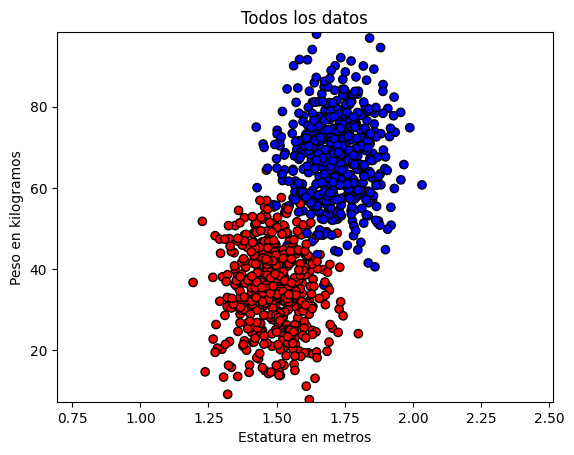

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X, y = make_blobs(n_samples=[500,500],
                  n_features = 2,
                  centers=[[1.49,35],[1.72,67]],
                  cluster_std = [[0.1,10],[0.1,10]],
                  random_state=1970)

x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura en metros")
plt.ylabel("Peso en kilogramos")

El ejemplo lo basaremos en datos simulados que representan\
una población de personas de género masculino\
niños y adultos, y se tienen dos características de ellos: estatura y peso

Dado que las escalas de peso y estaturas son muy diferentes
(dos ordenes de magnitud)
Antes de aplicar el clasificador, debemos llevarlas
a la misma escala:
* Se resta la media
* Se divide por la desviación estándar


In [ ]:
from sklearn import preprocessing
X_estandarizada = preprocessing.scale(X)
X = X_estandarizada

Y volvemos a mostrar los datos ...

Text(0, 0.5, 'Peso en kilogramos')

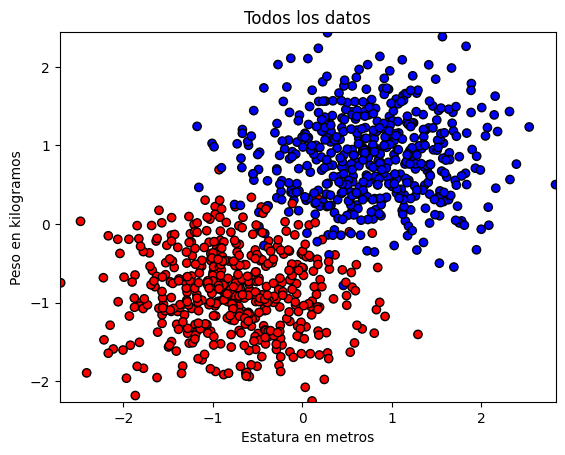

In [ ]:
x_min, x_max = X[:, 0].min() - .01, X[:, 0].max() + .01
y_min, y_max = X[:, 1].min() - .01, X[:, 1].max() + .01
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

# just plot the dataset first
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])
ax = plt.figure()
plt.title("Todos los datos")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright,
            edgecolors='k')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Estatura en metros")
plt.ylabel("Peso en kilogramos")

Ahora creamos los datos de prueba y entrenamiento

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.33, random_state=1970)

In [ ]:
from sklearn import neighbors
clfKNN = neighbors.KNeighborsClassifier(n_neighbors=21, # número de vecinos
                                        weights='distance', # pesos asignados a los vecinos al momento
                                                           # de tomar la decisión
                                                           # 'uniform', 'distance'
                                        algorithm='brute', # optimiza la ejecución del clasificador
                                                           # ‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’
                                        p=2, # usado para la fórmula de la distancia de Minkowski
                                        metric='minkowski')
clfKNN.fit(X_train,y_train)
y_esperado = y_test
y_predicho = clfKNN.predict(X_test)

In [ ]:
clfKNN

KNeighborsClassifier(algorithm='brute', n_neighbors=21, weights='distance')

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
print(accuracy_score(y_esperado,y_predicho))
print(recall_score(y_esperado,y_predicho))
print(precision_score(y_esperado,y_predicho))
print(confusion_matrix(y_esperado,y_predicho))

0.9757575757575757
0.9704142011834319
0.9820359281437125
[[158   3]
 [  5 164]]


Como se puede ver, el sistema es capaz de clasificar\
correctamente mas del 90% de los datos de prueba

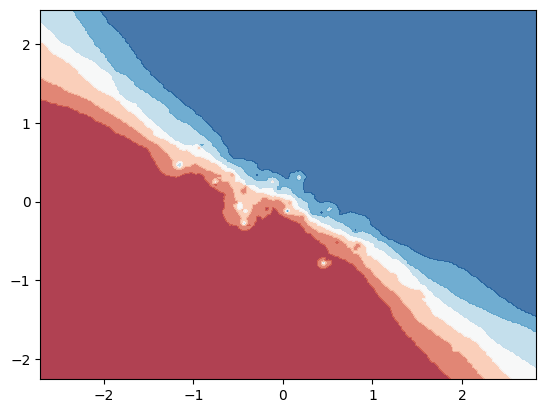

In [ ]:
Z = clfKNN.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=cm, alpha=.8)

Y esto es lo que el sistema sabe\
la elipse roja representa los niños\
el resto lo considera adultos